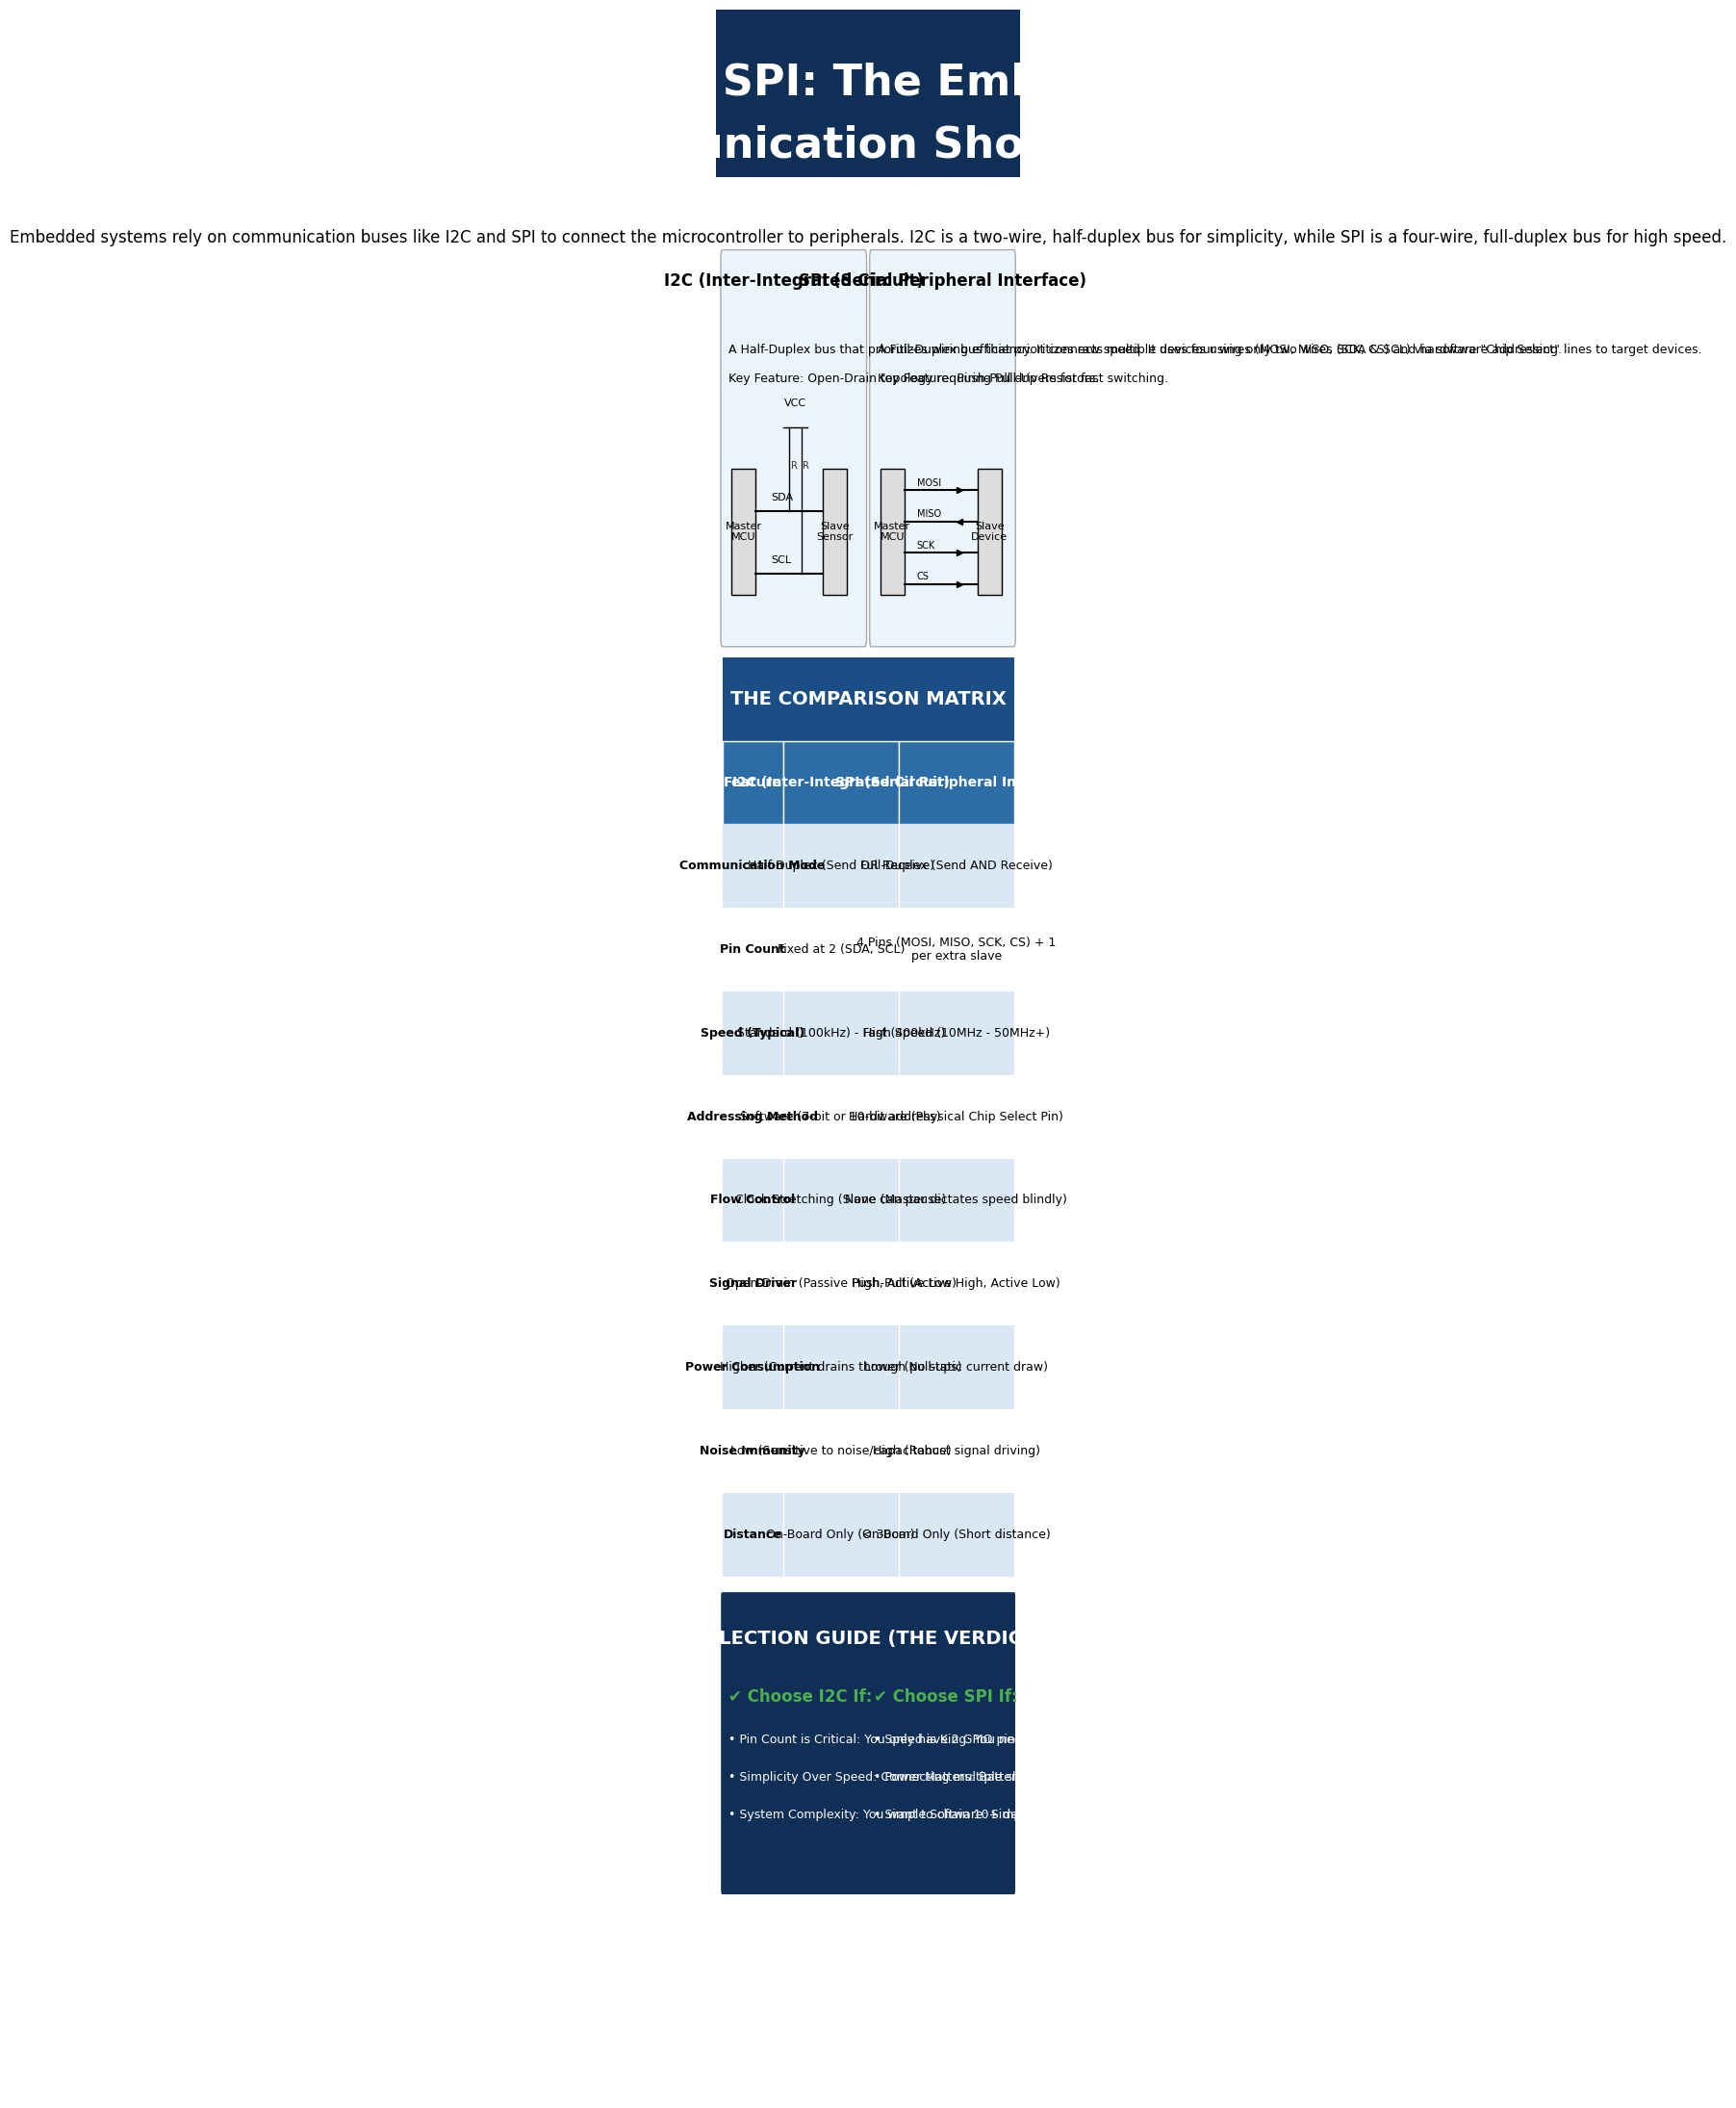

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def create_poster():
    # 1. Setup the Figure and Canvas
    # Use a tall aspect ratio similar to the poster
    fig, ax = plt.subplots(figsize=(12, 22))
    
    # Set limits to 0-100 for easier percentage-based layout
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    
    # Remove axes/ticks
    ax.axis('off')

    # Colors
    DARK_BLUE = '#0f2f57'
    LIGHT_BLUE_BG = '#ebf5fb'
    HEADER_BLUE = '#1a4e85' 
    WHITE = '#ffffff'
    GREEN = '#4caf50'
    GRAY_TEXT = '#333333'
    TABLE_ROW_ODD = '#dae8f5'
    TABLE_ROW_EVEN = '#ffffff'

    # --- HEADER SECTION ---
    # Title Background
    rect_header = patches.Rectangle((0, 92), 100, 8, linewidth=0, facecolor=DARK_BLUE)
    ax.add_patch(rect_header)
    
    # Title Text
    ax.text(50, 96.5, "I2C vs. SPI: The Embedded", 
            ha='center', va='center', fontsize=32, weight='bold', color=WHITE)
    ax.text(50, 93.5, "Communication Showdown", 
            ha='center', va='center', fontsize=32, weight='bold', color=WHITE)

    # Intro Paragraph
    intro_text = ("Embedded systems rely on communication buses like I2C and SPI to connect the "
                  "microcontroller to peripherals. I2C is a two-wire, half-duplex bus for simplicity, while "
                  "SPI is a four-wire, full-duplex bus for high speed.")
    ax.text(50, 89.5, intro_text, ha='center', va='top', fontsize=12, color='black')

    # --- DIAGRAMS SECTION (Top Split) ---
    
    # I2C Box (Left)
    rect_i2c = patches.FancyBboxPatch((2, 70), 47, 18, boxstyle="round,pad=0.5", 
                                      linewidth=1, edgecolor='#aaa', facecolor=LIGHT_BLUE_BG)
    ax.add_patch(rect_i2c)
    
    ax.text(25.5, 87, "I2C (Inter-Integrated Circuit)", ha='center', va='center', weight='bold', fontsize=12)
    i2c_desc = ("A Half-Duplex bus that prioritizes wiring efficiency. It connects multiple devices using "
                "only two wires (SDA & SCL) via software addressing.\n\n"
                "Key Feature: Open-Drain topology requiring Pull-Up Resistors.")
    ax.text(4, 84, i2c_desc, ha='left', va='top', fontsize=9)

    # I2C Schematic Drawing
    # Master Box
    ax.add_patch(patches.Rectangle((5, 72), 8, 6, facecolor='#ddd', edgecolor='black'))
    ax.text(9, 75, "Master\nMCU", ha='center', va='center', fontsize=8)
    # Slave Box
    ax.add_patch(patches.Rectangle((35, 72), 8, 6, facecolor='#ddd', edgecolor='black'))
    ax.text(39, 75, "Slave\nSensor", ha='center', va='center', fontsize=8)
    # Lines (SDA top, SCL bot)
    ax.plot([13, 35], [76, 76], color='black', linewidth=1.5) # SDA
    ax.text(18, 76.5, "SDA", fontsize=8)
    ax.plot([13, 35], [73, 73], color='black', linewidth=1.5) # SCL
    ax.text(18, 73.5, "SCL", fontsize=8)
    # Resistors (Simplified as zigzags or lines to VCC)
    ax.plot([24, 24], [76, 80], color='black', linewidth=1) # SDA up
    ax.plot([28, 28], [73, 80], color='black', linewidth=1) # SCL up
    ax.plot([22, 30], [80, 80], color='black', linewidth=1) # VCC bar
    ax.text(26, 81, "VCC", ha='center', fontsize=8)
    # Resistor symbols
    ax.text(24.5, 78, "R", ha='left', fontsize=7, color=GRAY_TEXT)
    ax.text(28.5, 78, "R", ha='left', fontsize=7, color=GRAY_TEXT)


    # SPI Box (Right)
    rect_spi = patches.FancyBboxPatch((51, 70), 47, 18, boxstyle="round,pad=0.5", 
                                      linewidth=1, edgecolor='#aaa', facecolor=LIGHT_BLUE_BG)
    ax.add_patch(rect_spi)
    
    ax.text(74.5, 87, "SPI (Serial Peripheral Interface)", ha='center', va='center', weight='bold', fontsize=12)
    spi_desc = ("A Full-Duplex bus that prioritizes raw speed. It uses four wires (MOSI, MISO, SCK, CS) "
                "and hardware \"Chip Select\" lines to target devices.\n\n"
                "Key Feature: Push-Pull drivers for fast switching.")
    ax.text(53, 84, spi_desc, ha='left', va='top', fontsize=9)

    # SPI Schematic Drawing
    # Master Box
    ax.add_patch(patches.Rectangle((54, 72), 8, 6, facecolor='#ddd', edgecolor='black'))
    ax.text(58, 75, "Master\nMCU", ha='center', va='center', fontsize=8)
    # Slave Box
    ax.add_patch(patches.Rectangle((86, 72), 8, 6, facecolor='#ddd', edgecolor='black'))
    ax.text(90, 75, "Slave\nDevice", ha='center', va='center', fontsize=8)
    # Lines
    y_lines = [77, 75.5, 74, 72.5]
    labels = ["MOSI", "MISO", "SCK", "CS"]
    for i, y in enumerate(y_lines):
        ax.plot([62, 86], [y, y], color='black', linewidth=1.5)
        ax.text(66, y+0.2, labels[i], fontsize=7)
        # Small arrows
        if labels[i] == "MISO": # Arrow left
            ax.plot(80, y, marker='<', markersize=4, color='black')
        else: # Arrow right
            ax.plot(80, y, marker='>', markersize=4, color='black')


    # --- TABLE SECTION ---
    
    # Table Header
    rect_table_head = patches.Rectangle((2, 65), 96, 4, facecolor=HEADER_BLUE)
    ax.add_patch(rect_table_head)
    ax.text(50, 67, "THE COMPARISON MATRIX", ha='center', va='center', color=WHITE, weight='bold', fontsize=14)

    # Table Content Configuration
    # Columns: Feature (Width 20), I2C (Width 38), SPI (Width 38)
    rows = [
        ("Communication Mode", "Half-Duplex (Send OR Receive)", "Full-Duplex (Send AND Receive)"),
        ("Pin Count", "Fixed at 2 (SDA, SCL)", "4 Pins (MOSI, MISO, SCK, CS) + 1\nper extra slave"),
        ("Speed (Typical)", "Standard (100kHz) - Fast (400kHz)", "High Speed (10MHz - 50MHz+)"),
        ("Addressing Method", "Software (7-bit or 10-bit address)", "Hardware (Physical Chip Select Pin)"),
        ("Flow Control", "Clock Stretching (Slave can pause)", "None (Master dictates speed blindly)"),
        ("Signal Driver", "Open-Drain (Passive High, Active Low)", "Push-Pull (Active High, Active Low)"),
        ("Power Consumption", "Higher (Current drains through pull-ups)", "Lower (No static current draw)"),
        ("Noise Immunity", "Low (Sensitive to noise/capacitance)", "High (Robust signal driving)"),
        ("Distance", "On-Board Only (< 30cm)", "On-Board Only (Short distance)")
    ]

    # Draw Table
    y_pos = 65
    row_height = 4
    
    # Column Headers
    ax.add_patch(patches.Rectangle((2, 61), 20, 4, facecolor='#2c6da8', edgecolor='white'))
    ax.text(12, 63, "Feature", ha='center', va='center', color=WHITE, weight='bold', fontsize=10)
    
    ax.add_patch(patches.Rectangle((22, 61), 38, 4, facecolor='#2c6da8', edgecolor='white'))
    ax.text(41, 63, "I2C (Inter-Integrated Circuit)", ha='center', va='center', color=WHITE, weight='bold', fontsize=10)
    
    ax.add_patch(patches.Rectangle((60, 61), 38, 4, facecolor='#2c6da8', edgecolor='white'))
    ax.text(79, 63, "SPI (Serial Peripheral Interface)", ha='center', va='center', color=WHITE, weight='bold', fontsize=10)

    y_pos = 61
    
    for i, row in enumerate(rows):
        feature, i2c_val, spi_val = row
        y_pos -= row_height
        
        # Row Background
        color = TABLE_ROW_ODD if i % 2 == 0 else TABLE_ROW_EVEN
        ax.add_patch(patches.Rectangle((2, y_pos), 96, row_height, facecolor=color))
        
        # Text
        ax.text(12, y_pos + row_height/2, feature, ha='center', va='center', fontsize=9, weight='bold')
        ax.text(41, y_pos + row_height/2, i2c_val, ha='center', va='center', fontsize=9)
        ax.text(79, y_pos + row_height/2, spi_val, ha='center', va='center', fontsize=9)
        
        # Vertical dividers
        ax.plot([22, 22], [y_pos, y_pos+row_height], color='white', linewidth=1)
        ax.plot([60, 60], [y_pos, y_pos+row_height], color='white', linewidth=1)


    # --- FOOTER / SELECTION GUIDE ---
    footer_top = y_pos - 2
    
    # Footer Header
    rect_footer = patches.FancyBboxPatch((2, 10), 96, 14, boxstyle="round,pad=0.2", 
                                         color=DARK_BLUE)
    ax.add_patch(rect_footer)
    
    ax.text(50, 22, "SELECTION GUIDE (THE VERDICT)", ha='center', va='center', 
            color=WHITE, weight='bold', fontsize=14)

    # Footer Content - Left (I2C)
    ax.text(4, 19, "✔ Choose I2C If:", color=GREEN, weight='bold', fontsize=12)
    i2c_points = [
        "• Pin Count is Critical: You only have 2 GPIO pins left.",
        "• Simplicity Over Speed: Connecting multiple slow sensors.",
        "• System Complexity: You want to chain 10+ devices without routing CS lines."
    ]
    for k, point in enumerate(i2c_points):
        ax.text(4, 17 - (k*1.8), point, color=WHITE, fontsize=9)

    # Footer Content - Right (SPI)
    ax.text(52, 19, "✔ Choose SPI If:", color=GREEN, weight='bold', fontsize=12)
    spi_points = [
        "• Speed is King: You need to stream data (Displays, SD Cards).",
        "• Power Matters: Battery-operated devices (saves pull-up current).",
        "• Simple Software: Simple transmit/receive logic needed."
    ]
    for k, point in enumerate(spi_points):
        ax.text(52, 17 - (k*1.8), point, color=WHITE, fontsize=9)

    # Save and Show
    plt.tight_layout()
    plt.savefig('i2c_vs_spi_poster.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

if __name__ == "__main__":
    create_poster()
